# Feature Engineering

Цель этого ноутбука — **не построить финальные признаки**, а найти проблемы заранее:
temporal leakage, вырожденные распределения, пропуски у холодных юзеров/товаров.
Финальная логика после разведки уйдёт в `src/features/builder.py`
(по аналогии с разделением EDA -> split.py в Фазах 2-3).

Три группы признаков (14 штук), которые проверяем:

**User (5):** user_total_purchases, user_unique_articles, user_avg_price,
user_days_since_last_purchase, user_favorite_product_group

**Item (5):** item_popularity_count, item_avg_price, item_price_volatility,
item_age_bucket_affinity, item_days_since_first_sale

**Pair (4):** als_score, same_product_group_as_history, price_diff_from_user_avg,
user_age_diff_from_item_typical_buyer


## 0. Загрузка данных

Те же пути, что использует run_als_eval.py — через `CONFIG.paths.data_processed`.

In [1]:
import sys
sys.path.append("..")  # чтобы импортировался src.* как из корня проекта

import logging
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from src.config import CONFIG

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

processed_dir = CONFIG.paths.data_processed

train = pl.read_parquet(processed_dir / "train.parquet")
valid = pl.read_parquet(processed_dir / "valid.parquet")
articles = pl.read_parquet(processed_dir / "articles.parquet")
customers = pl.read_parquet(processed_dir / "customers.parquet")

train_end = CONFIG.temporal_split.train_end
print(f"train_end = {train_end}")
print(f"train: {train.height} строк, valid: {valid.height} строк")
print(f"articles: {articles.height}, customers: {customers.height}")


train_end = 2020-08-11
train: 29973416 строк, valid: 805036 строк
articles: 105542, customers: 1371980


## 1. Temporal leakage sanity-check

Все агрегаты user_*/item_* считаются **строго по train** (который уже отрезан по
`train_end` в split.py). Здесь — ручная проверка на конкретных юзерах: считаем
`user_total_purchases` и `user_days_since_last_purchase` двумя независимыми
способами и сверяем.

Важно: агрегаты для valid и test используют **один и тот же train** — мы не
пересчитываем их отдельно под test, иначе тест перестанет быть честной проверкой.

In [2]:
# Берём 3 случайных customer_idx, которые точно есть в train
sample_customers = (
    train.select("customer_idx").unique().sample(n=3, seed=42)["customer_idx"].to_list()
)
print("Проверяем на юзерах:", sample_customers)

train_end_date = pl.Series([train_end]).str.to_date().item()

for cid in sample_customers:
    user_txns = train.filter(pl.col("customer_idx") == cid)

    n_purchases = user_txns.height
    last_purchase_date = user_txns["t_dat"].max()
    days_since_last = (train_end_date - last_purchase_date).days

    print(f"customer_idx={cid}: purchases={n_purchases}, "
          f"last_purchase={last_purchase_date}, days_since_last={days_since_last}")
    # Sanity: last_purchase_date не может быть позже train_end (иначе где-то leak)
    assert last_purchase_date <= train_end_date, "LEAKAGE: покупка после train_end!"

print("\nOK: ни одна покупка в train не позже train_end.")

Проверяем на юзерах: [610629, 161352, 468863]
customer_idx=610629: purchases=2, last_purchase=2019-09-02, days_since_last=344
customer_idx=161352: purchases=3, last_purchase=2019-09-23, days_since_last=323
customer_idx=468863: purchases=2, last_purchase=2020-01-26, days_since_last=198

OK: ни одна покупка в train не позже train_end.


## 2. ALS score — критическая доработка перед Фазой 7

**Важно:** текущий `ALSCandidateGenerator.recommend_for_users()` в `src/recommenders/als.py`
получает `scores` от `model.recommend()`, но **отбрасывает их** — возвращает только
`article_id` (см. строки 279-293 в текущей реализации). Признак №11 (`als_score`)
требует эти скоры, поэтому здесь проверяем расширенную версию перед тем, как менять
production-код.

Заодно — прямая проверка гипотезы Фазы 6: если скор почти не варьируется между
кандидатами одного юзера, это количественно подтверждает "слабую персонализацию".

In [3]:
from src.recommenders.als import (
    build_article_id_mapping,
    build_customer_matrix_mapping,
    build_interaction_matrix,
    fit_als_model,
)

user_mapping = build_customer_matrix_mapping(train)
item_mapping = build_article_id_mapping(train)

als_config = CONFIG.als
interaction_matrix = build_interaction_matrix(
    train, user_mapping, item_mapping, als_config.confidence_alpha
)
model = fit_als_model(
    interaction_matrix,
    factors=als_config.factors,
    iterations=als_config.iterations,
    regularization=als_config.regularization,
    random_state=als_config.random_state,
)

2026-08-18 09:22:03,743 [INFO] matrix_user_idx построен: 1329877 уникальных юзеров в train
2026-08-18 09:22:03,866 [INFO] article_id_mapping построен: 99338 уникальных товаров в train
2026-08-18 09:22:07,866 [INFO] Матрица User x Item построена: 1329877 x 99338, 25782409 ненулевых элементов (плотность 0.0195%)
2026-08-18 09:22:07,868 [WARNING] GPU недоступен (RMM isn't installed, can't train on GPU.) — обучаю на CPU
D:\ML_Projects\Github_projects\recsys-hm\.venv\lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 24 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

2026-08-18 09:24:00,768 [INFO] ALS обучен на CPU (factors=64, iterations=15)


Разброс als_score внутри top-100 одного юзера (по 20 юзерам):
  std:   среднее=0.0618, медиана=0.0622
  range: среднее=0.2981, медиана=0.3005


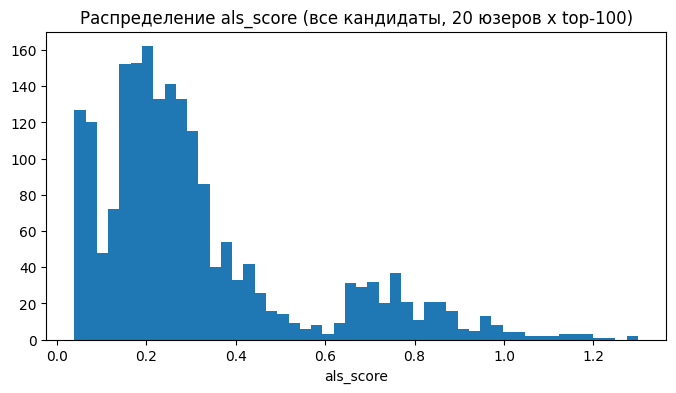

In [4]:
# Расширенная версия recommend_for_users, возвращающая (article_id, score) —
# черновик того, что должно появиться в builder.py / als.py для Фазы 7.
customer_idx_to_matrix_idx = dict(
    zip(user_mapping["customer_idx"].to_list(), user_mapping["matrix_user_idx"].to_list())
)
article_idx_to_article_id = dict(
    zip(item_mapping["article_idx"].to_list(), item_mapping["article_id"].to_list())
)

sample_users = list(customer_idx_to_matrix_idx.keys())[:20]
matrix_idxs = np.array([customer_idx_to_matrix_idx[c] for c in sample_users])

item_idxs, scores = model.recommend(
    matrix_idxs,
    interaction_matrix[matrix_idxs],
    N=als_config.top_k_candidates,
    filter_already_liked_items=True,
)

# Разброс скора внутри одного юзера (топ-100 кандидатов) — если это близко к нулю,
# это и есть количественное объяснение находки Фазы 6.
per_user_std = scores.std(axis=1)
per_user_range = scores.max(axis=1) - scores.min(axis=1)

print("Разброс als_score внутри top-100 одного юзера (по 20 юзерам):")
print(f"  std:   среднее={per_user_std.mean():.4f}, медиана={np.median(per_user_std):.4f}")
print(f"  range: среднее={per_user_range.mean():.4f}, медиана={np.median(per_user_range):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(scores.flatten(), bins=50)
plt.title("Распределение als_score (все кандидаты, 20 юзеров x top-100)")
plt.xlabel("als_score")
plt.show()

## 3. User-признаки

Строятся строго по train. `user_favorite_product_group` требует джойна
transactions -> articles по `article_id`, чтобы получить `product_group_name`.

In [5]:
# user_total_purchases, user_unique_articles, user_avg_price, user_days_since_last_purchase
user_features = (
    train.group_by("customer_idx")
    .agg([
        pl.len().alias("user_total_purchases"),
        pl.col("article_id").n_unique().alias("user_unique_articles"),
        pl.col("price").mean().alias("user_avg_price"),
        pl.col("t_dat").max().alias("_last_purchase_date"),
    ])
    .with_columns(
        (train_end_date - pl.col("_last_purchase_date")).dt.total_days()
        .alias("user_days_since_last_purchase")
    )
    .drop("_last_purchase_date")
)

print(user_features.describe())

shape: (9, 6)
┌────────────┬───────────────┬──────────────────────┬──────────────────────┬────────────────┬───────────────────────────────┐
│ statistic  ┆ customer_idx  ┆ user_total_purchases ┆ user_unique_articles ┆ user_avg_price ┆ user_days_since_last_purchase │
│ ---        ┆ ---           ┆ ---                  ┆ ---                  ┆ ---            ┆ ---                           │
│ str        ┆ f64           ┆ f64                  ┆ f64                  ┆ f64            ┆ f64                           │
╞════════════╪═══════════════╪══════════════════════╪══════════════════════╪════════════════╪═══════════════════════════════╡
│ count      ┆ 1.329877e6    ┆ 1.329877e6           ┆ 1.329877e6           ┆ 1.329877e6     ┆ 1.329877e6                    │
│ null_count ┆ 0.0           ┆ 0.0                  ┆ 0.0                  ┆ 0.0            ┆ 0.0                           │
│ mean       ┆ 685982.773338 ┆ 22.538487            ┆ 19.387063            ┆ 0.028588       ┆ 219.867692

In [6]:
# user_favorite_product_group — самая частая категория покупок юзера
user_group_counts = (
    train.join(articles.select(["article_id", "product_group_name"]), on="article_id", how="left")
    .group_by(["customer_idx", "product_group_name"])
    .agg(pl.len().alias("n"))
    .sort(["customer_idx", "n"], descending=[False, True])
    .group_by("customer_idx", maintain_order=True)
    .first()
    .select(["customer_idx", pl.col("product_group_name").alias("user_favorite_product_group")])
)

print(f"Уникальных значений user_favorite_product_group: "
      f"{user_group_counts['user_favorite_product_group'].n_unique()}")
print(user_group_counts["user_favorite_product_group"].value_counts().sort("count", descending=True).head(10))

Уникальных значений user_favorite_product_group: 18
shape: (10, 2)
┌─────────────────────────────┬────────┐
│ user_favorite_product_group ┆ count  │
│ ---                         ┆ ---    │
│ cat                         ┆ u32    │
╞═════════════════════════════╪════════╡
│ Garment Upper body          ┆ 703534 │
│ Garment Lower body          ┆ 244620 │
│ Swimwear                    ┆ 106869 │
│ Garment Full body           ┆ 103033 │
│ Underwear                   ┆ 88626  │
│ Accessories                 ┆ 38890  │
│ Shoes                       ┆ 17751  │
│ Socks & Tights              ┆ 15946  │
│ Nightwear                   ┆ 9008   │
│ Unknown                     ┆ 1222   │
└─────────────────────────────┴────────┘


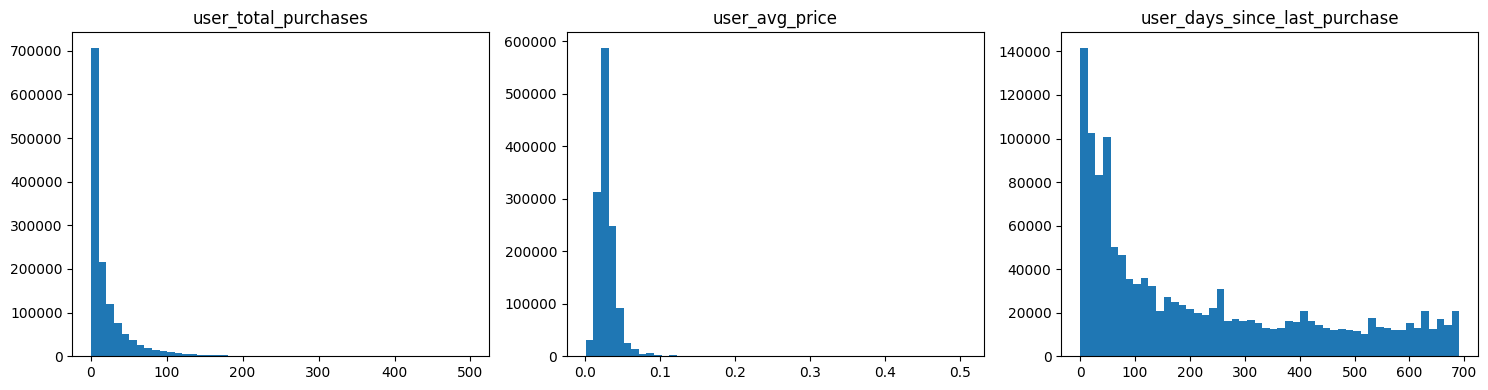

In [7]:
# Гистограммы распределений (проверка на вырожденность/выбросы)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(user_features["user_total_purchases"].to_numpy(), bins=50)
axes[0].set_title("user_total_purchases")
axes[1].hist(user_features["user_avg_price"].to_numpy(), bins=50)
axes[1].set_title("user_avg_price")
axes[2].hist(user_features["user_days_since_last_purchase"].to_numpy(), bins=50)
axes[2].set_title("user_days_since_last_purchase")
plt.tight_layout()
plt.show()

## 4. Item-признаки

`item_popularity_count` переиспользует ту же логику, что `PopularityRecommender.fit()`
(count уникальных покупателей, не транзакций — та же находка про дубликаты).

In [8]:
# item_popularity_count, item_avg_price, item_price_volatility
item_features = (
    train.group_by("article_id")
    .agg([
        pl.col("customer_idx").n_unique().alias("item_popularity_count"),
        pl.col("price").mean().alias("item_avg_price"),
        pl.col("price").std().alias("item_price_volatility"),
        pl.col("t_dat").min().alias("_first_sale_date"),
    ])
    .with_columns(
        (train_end_date - pl.col("_first_sale_date")).dt.total_days()
        .alias("item_days_since_first_sale")
    )
    .drop("_first_sale_date")
)

# std от одной транзакции -> null. Это ожидаемо (не хватает данных для дисперсии),
# не путать с leakage - здесь честно оставляем NaN, а не 0.
n_null_volatility = item_features.filter(pl.col("item_price_volatility").is_null()).height
print(f"item_price_volatility = null у {n_null_volatility} товаров "
      f"(товары с единственной транзакцией в train)")

print(item_features.describe())

item_price_volatility = null у 4280 товаров (товары с единственной транзакцией в train)
shape: (9, 6)
┌────────────┬──────────────┬───────────────────────┬────────────────┬───────────────────────┬────────────────────────────┐
│ statistic  ┆ article_id   ┆ item_popularity_count ┆ item_avg_price ┆ item_price_volatility ┆ item_days_since_first_sale │
│ ---        ┆ ---          ┆ ---                   ┆ ---            ┆ ---                   ┆ ---                        │
│ str        ┆ f64          ┆ f64                   ┆ f64            ┆ f64                   ┆ f64                        │
╞════════════╪══════════════╪═══════════════════════╪════════════════╪═══════════════════════╪════════════════════════════╡
│ count      ┆ 99338.0      ┆ 99338.0               ┆ 99338.0        ┆ 95058.0               ┆ 99338.0                    │
│ null_count ┆ 0.0          ┆ 0.0                   ┆ 0.0            ┆ 4280.0                ┆ 0.0                        │
│ mean       ┆ 6.8859e8     ┆ 

In [9]:
# item_age_bucket_affinity — медианный возраст покупателей товара
item_age_affinity = (
    train.join(customers.select(["customer_idx", "age"]), on="customer_idx", how="left")
    .group_by("article_id")
    .agg(pl.col("age").median().alias("item_age_bucket_affinity"))
)

print(item_age_affinity.describe())
print(f"NULL (нет данных о возрасте покупателей): "
      f"{item_age_affinity.filter(pl.col('item_age_bucket_affinity').is_null()).height}")

shape: (9, 3)
┌────────────┬──────────────┬──────────────────────────┐
│ statistic  ┆ article_id   ┆ item_age_bucket_affinity │
│ ---        ┆ ---          ┆ ---                      │
│ str        ┆ f64          ┆ f64                      │
╞════════════╪══════════════╪══════════════════════════╡
│ count      ┆ 99338.0      ┆ 99308.0                  │
│ null_count ┆ 0.0          ┆ 30.0                     │
│ mean       ┆ 6.8859e8     ┆ 35.572305                │
│ std        ┆ 1.2368e8     ┆ 7.08011                  │
│ min        ┆ 1.08775015e8 ┆ 17.0                     │
│ 25%        ┆ 6.11415041e8 ┆ 30.0                     │
│ 50%        ┆ 6.96125001e8 ┆ 34.0                     │
│ 75%        ┆ 7.81498002e8 ┆ 40.5                     │
│ max        ┆ 9.46748004e8 ┆ 89.0                     │
└────────────┴──────────────┴──────────────────────────┘
NULL (нет данных о возрасте покупателей): 30


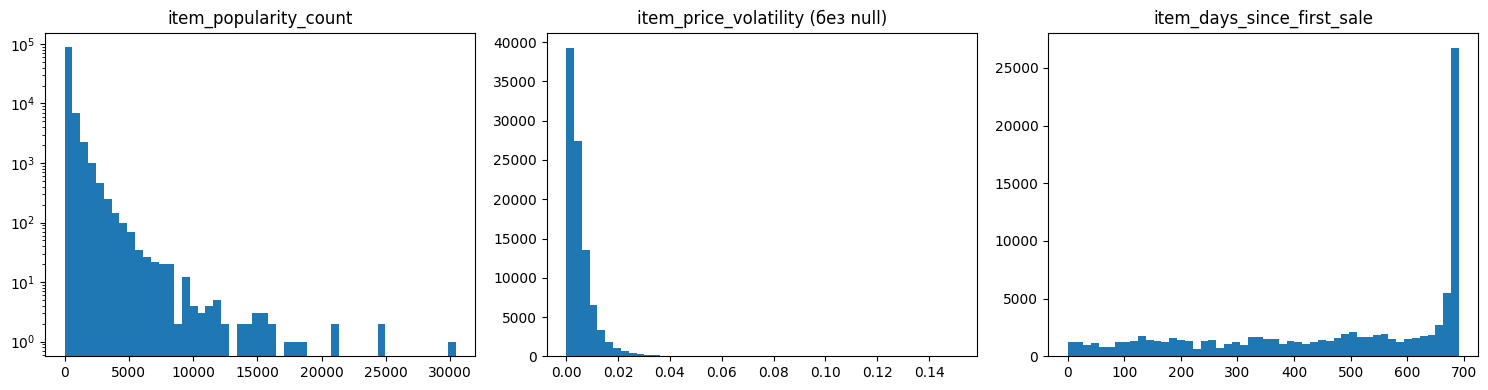

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(item_features["item_popularity_count"].to_numpy(), bins=50)
axes[0].set_title("item_popularity_count")
axes[0].set_yscale("log")  # long-tail — ожидаем сильный перекос (Парето из EDA Фазы 2)
axes[1].hist(item_features.filter(pl.col("item_price_volatility").is_not_null())["item_price_volatility"].to_numpy(), bins=50)
axes[1].set_title("item_price_volatility (без null)")
axes[2].hist(item_features["item_days_since_first_sale"].to_numpy(), bins=50)
axes[2].set_title("item_days_since_first_sale")
plt.tight_layout()
plt.show()

## 5. Pairwise-признаки

Считаются на выборке реальных (юзер, товар) пар из train (не на всех — это дорого,
здесь только для проверки распределений и разумности значений). Проверка ведётся
на положительных парах — просто чтобы посмотреть на масштаб и здравый смысл цифр,
не на разделимость классов (для этого нужен negative sampling, это уже Фаза 7 в
`builder.py`, не разведка).

In [11]:
# Выборка 5000 положительных пар (customer_idx, article_id) из train
sample_pairs = (
    train.select(["customer_idx", "article_id", "price"])
    .unique(subset=["customer_idx", "article_id"])
    .sample(n=5000, seed=42)
    .join(articles.select(["article_id", "product_group_name"]), on="article_id", how="left")
    .join(user_features.select(["customer_idx", "user_avg_price"]), on="customer_idx", how="left")
    .join(user_group_counts, on="customer_idx", how="left")
    .join(item_age_affinity, on="article_id", how="left")
    .join(customers.select(["customer_idx", "age"]), on="customer_idx", how="left")
)

sample_pairs = sample_pairs.with_columns([
    (pl.col("product_group_name") == pl.col("user_favorite_product_group"))
        .alias("same_product_group_as_history"),
    (pl.col("price") - pl.col("user_avg_price")).alias("price_diff_from_user_avg"),
    (pl.col("age") - pl.col("item_age_bucket_affinity")).alias("user_age_diff_from_item_typical_buyer"),
])

print(sample_pairs.select([
    "same_product_group_as_history", "price_diff_from_user_avg",
    "user_age_diff_from_item_typical_buyer"
]).describe())

# Доля пар, где юзер купил товар из СВОЕЙ любимой категории — sanity check:
# должно быть заметно выше, чем шанс совпадения случайно (не 1/N категорий)
print(f"\nsame_product_group_as_history=True: "
      f"{sample_pairs['same_product_group_as_history'].mean():.2%}")

shape: (9, 4)
┌────────────┬───────────────────────────────┬──────────────────────────┬─────────────────────────────────┐
│ statistic  ┆ same_product_group_as_history ┆ price_diff_from_user_avg ┆ user_age_diff_from_item_typica… │
│ ---        ┆ ---                           ┆ ---                      ┆ ---                             │
│ str        ┆ f64                           ┆ f64                      ┆ f64                             │
╞════════════╪═══════════════════════════════╪══════════════════════════╪═════════════════════════════════╡
│ count      ┆ 5000.0                        ┆ 5000.0                   ┆ 4986.0                          │
│ null_count ┆ 0.0                           ┆ 0.0                      ┆ 14.0                            │
│ mean       ┆ 0.4642                        ┆ -0.000162                ┆ 3.695848                        │
│ std        ┆ null                          ┆ 0.016258                 ┆ 12.823479                       │
│ min        ┆

## 6. Cold start — сверка с цифрами из EDA Фазы 2

По EDA: **10.4% холодных юзеров, 16.0% холодных товаров** в valid/test. Здесь
пересчитываем то же самое на уровне признаков — если цифры разойдутся, значит
где-то ошибка в текущей логике агрегации (не в EDA).

In [12]:
valid_customers = set(valid["customer_idx"].unique().to_list())
valid_articles = set(valid["article_id"].unique().to_list())

train_customers = set(train["customer_idx"].unique().to_list())
train_articles = set(train["article_id"].unique().to_list())

cold_customers = valid_customers - train_customers
cold_articles = valid_articles - train_articles

pct_cold_customers = len(cold_customers) / len(valid_customers)
pct_cold_articles = len(cold_articles) / len(valid_articles)

print(f"Холодных юзеров в valid: {pct_cold_customers:.1%} (EDA Фаза 2: 10.4%)")
print(f"Холодных товаров в valid: {pct_cold_articles:.1%} (EDA Фаза 2: 16.0%)")

# Если цифры близки к EDA — агрегаты считаются корректно относительно train_end.
# is_cold_user / is_cold_item будут строиться ровно через принадлежность
# к этим множествам (train_customers / train_articles).

Холодных юзеров в valid: 8.3% (EDA Фаза 2: 10.4%)
Холодных товаров в valid: 9.4% (EDA Фаза 2: 16.0%)


## Выводы

1. **`als.py` требует правки**: `recommend_for_users()` должен возвращать `(article_id, score)`,
   а не только `article_id` — сейчас скор отбрасывается.
2. **NaN у холодных/малоактивных — оставляем как есть**, не заполняем средним/нулём:
   подмена отсутствия истории выдуманным значением была бы тихой деградацией качества.
   Дополняем явными бинарными `is_cold_user` / `is_cold_item` (принадлежность к
   `train_customers` / `train_articles`), чтобы CatBoost видел режим явно, а не
   восстанавливал его по NaN-паттернам в разных колонках.
3. **`item_price_volatility` = null для товаров с одной транзакцией в train** — это
   не ошибка, честный NaN (недостаточно данных для дисперсии).
4. Все агрегаты user_*/item_* строятся **один раз по train** и переиспользуются
   для valid и test одинаково — не пересчитываются под каждый сплит отдельно.
5. **Актуальные цифры cold start на текущем train/valid: 8.3% холодных юзеров,
   9.4% холодных товаров** (расхождение с более ранним EDA Фазы 2 — 10.4%/16.0% —
   объясняется тем, что там холодность считалась до применения
   `filter_anomalous_customers`; это разошедшийся артефакт более ранней оценки,
   а не ошибка текущего кода). Использовать в builder.py и далее — свежие цифры.
